# 1. Introduction
#### Modélisation avec XGBoost — Agrégation mensuelle

**Objectif**

Entraîner un modèle XGBoost sur les données mensuelles produites par le
feature engineering mensuel (`dataset_ml_mensuel.csv`), afin de :
- prédire les quantités de carburant commandées par mois et par station ;
- comparer les résultats avec Random Forest et les modèles ARIMA/SARIMA
  sur la **même échelle temporelle**.

## 2. Importation des bibliothèques

In [4]:
# IMPORTATION DES BIBLIOTHÈQUES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
from scipy import stats

pd.set_option('display.max_columns', None)
print("Bibliothèques importées.")


Bibliothèques importées.


## 3. Chargement du dataset mensuel

On charge `dataset_ml_mensuel.csv` — produit par le notebook FE mensuel.
Chaque ligne = 1 mois × 1 station × 1 article.

In [6]:
# CHARGEMENT DU DATASET MENSUEL

df_ml = pd.read_csv("../data/propre/dataset_ml_mensuel.csv", parse_dates=['mois'])

print(f"Dimensions : {df_ml.shape[0]:,} lignes x {df_ml.shape[1]} colonnes")
print(f"Période    : {df_ml['mois'].min().date()} → {df_ml['mois'].max().date()}")
print(f"Stations   : {df_ml['Code Station'].nunique()}")
print(f"Articles   : {df_ml['N° article'].nunique()}")
print()
display(df_ml.head(10))


Dimensions : 5,473 lignes x 24 colonnes
Période    : 2021-01-01 → 2025-12-01
Stations   : 89
Articles   : 2



,Code Station,N° article,mois_periode,quantite_mois,nb_commandes,mois,annee,num_mois,trimestre,mois_sin,mois_cos,est_t1,est_t4,saison_benin,Lag_1,Lag_3,Lag_12,Rolling_3m,Rolling_6m,Rolling_12m,Rolling_Std_3m,ratio_tendance,StationEncoded,ProduitEncoded
0,ST0001,A0001,2023-10,79000,4,2023-10-01,2023,10,4,-8.660254e-01,5.000000e-01,0,1,3,20000.0,95000.0,20000.0,65000.000000,68833.333333,57166.666667,39686.269666,1.1370,0,0
1,ST0001,A0001,2023-11,70000,4,2023-11-01,2023,11,4,-5.000000e-01,8.660254e-01,0,1,3,79000.0,80000.0,24000.0,59666.666667,74000.000000,62083.333333,34355.979586,0.9611,0,0
2,ST0001,A0001,2023-12,55000,4,2023-12-01,2023,12,4,-2.449294e-16,1.000000e+00,0,1,0,70000.0,20000.0,49000.0,56333.333333,68166.666667,65916.666667,31785.741038,0.8546,0,0
3,ST0001,A0001,2024-01,55000,5,2024-01-01,2024,1,1,5.000000e-01,8.660254e-01,1,0,0,55000.0,79000.0,56000.0,68000.000000,66500.000000,66416.666667,12124.355653,1.0238,0,0
4,ST0001,A0001,2024-02,105000,7,2024-02-01,2024,2,1,8.660254e-01,5.000000e-01,1,0,0,55000.0,70000.0,34000.0,60000.000000,59833.333333,66333.333333,8660.254038,0.9045,0,0
5,ST0001,A0001,2024-03,87000,5,2024-03-01,2024,3,1,1.000000e+00,6.123234e-17,1,0,1,105000.0,55000.0,90000.0,71666.666667,64000.000000,72250.000000,28867.513459,0.9919,0,0
6,ST0001,A0001,2024-04,93000,5,2024-04-01,2024,4,2,8.660254e-01,-5.000000e-01,0,0,1,87000.0,55000.0,48000.0,82333.333333,75166.666667,72000.000000,25324.559884,1.1435,0,0
7,ST0001,A0001,2024-05,143000,9,2024-05-01,2024,5,2,5.000000e-01,-8.660254e-01,0,0,2,93000.0,105000.0,105000.0,95000.000000,77500.000000,75750.000000,9165.151390,1.2541,0,0
8,ST0001,A0001,2024-06,103000,8,2024-06-01,2024,6,2,1.224647e-16,-1.000000e+00,0,0,2,143000.0,87000.0,65000.0,107666.666667,89666.666667,78916.666667,30746.273487,1.3643,0,0
9,ST0001,A0001,2024-07,96000,7,2024-07-01,2024,7,3,-5.000000e-01,-8.660254e-01,0,0,2,103000.0,93000.0,95000.0,113000.000000,97666.666667,82083.333333,26457.513111,1.3766,0,0


In [14]:
# ==========================================================
# Filtrage des couples ayant au moins 12 mois
# ==========================================================

nb_mois = (
    df_ml
    .groupby(["Code Station", "N° article"])
    .size()
    .reset_index(name="nb_mois")
)

couples_valides = nb_mois[
    nb_mois["nb_mois"] >= 12
][["Code Station", "N° article"]]

df_ml = (
    df_ml.merge(
        couples_valides,
        on=["Code Station", "N° article"],
        how="inner"
    )
)

print("Nombre de couples :", len(couples_valides))
print("Nombre de lignes :", len(df_ml))

Nombre de couples : 147
Nombre de lignes : 5338


Distribution de quantite_mois :
count       5338.0
mean       36697.0
std        40843.0
min         1000.0
25%        15000.0
50%        25000.0
75%        46750.0
max      1078000.0
Name: quantite_mois, dtype: float64



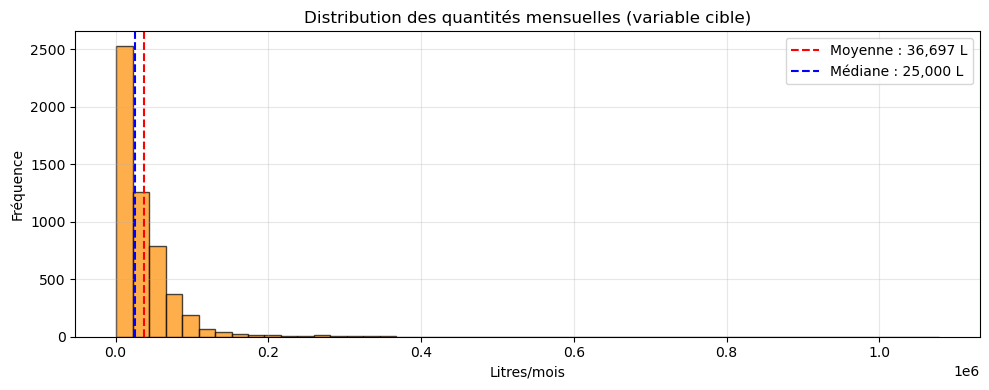

In [16]:
# VÉRIFICATION DE LA VARIABLE CIBLE

print("Distribution de quantite_mois :")
print(df_ml['quantite_mois'].describe().round(0))
print()

plt.figure(figsize=(10, 4))
plt.hist(df_ml['quantite_mois'], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
plt.axvline(df_ml['quantite_mois'].mean(), color='red', linestyle='--',
            label=f"Moyenne : {df_ml['quantite_mois'].mean():,.0f} L")
plt.axvline(df_ml['quantite_mois'].median(), color='blue', linestyle='--',
            label=f"Médiane : {df_ml['quantite_mois'].median():,.0f} L")
plt.title('Distribution des quantités mensuelles (variable cible)')
plt.xlabel('Litres/mois')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Sélection des variables explicatives

On utilise exactement les features produites par le FE mensuel —
**identiques au notebook Random Forest mensuel** pour une comparaison équitable.

| Catégorie | Features |
|---|---|
| Identifiants | StationEncoded, ProduitEncoded |
| Temporelles | annee, num_mois, trimestre, mois_sin, mois_cos, saison_benin |
| Lags mensuels | Lag_1, Lag_3, Lag_12 |
| Rolling mensuel | Rolling_3m, Rolling_6m, Rolling_12m, Rolling_Std_3m, ratio_tendance |
| Métier | nb_commandes |

In [18]:
# DÉFINITION DES FEATURES ET DE LA CIBLE
# Identiques au notebook RF mensuel → comparaison équitable

FEATURES = [
    # Identifiants encodés
    'StationEncoded',
    'ProduitEncoded',

    # Temporelles
    'annee',
    'num_mois',
    'trimestre',
    'mois_sin',
    'mois_cos',
    'saison_benin',

    # Lags mensuels
    'Lag_1',     # mois précédent
    'Lag_3',     # il y a 3 mois
    'Lag_12',    # même mois l'année passée → saisonnalité annuelle

    # Rolling windows mensuelles
    'Rolling_3m',      # tendance 3 mois
    'Rolling_6m',      # tendance 6 mois
    'Rolling_12m',     # tendance annuelle
    'Rolling_Std_3m',  # volatilité court terme
    'ratio_tendance',  # accélération demande

    # Métier
    'nb_commandes',    # nb jours commandés dans le mois
]

TARGET = 'quantite_mois'

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f"Features : {len(FEATURES)}")
print(f"X : {X.shape}")
print(f"y : {y.shape}")
print()
display(X.head(5))


Features : 17
X : (5338, 17)
y : (5338,)



,StationEncoded,ProduitEncoded,annee,num_mois,trimestre,mois_sin,mois_cos,saison_benin,Lag_1,Lag_3,Lag_12,Rolling_3m,Rolling_6m,Rolling_12m,Rolling_Std_3m,ratio_tendance,nb_commandes
0,0,0,2023,10,4,-8.660254e-01,0.500000,3,20000.0,95000.0,20000.0,65000.000000,68833.333333,57166.666667,39686.269666,1.1370,4
1,0,0,2023,11,4,-5.000000e-01,0.866025,3,79000.0,80000.0,24000.0,59666.666667,74000.000000,62083.333333,34355.979586,0.9611,4
2,0,0,2023,12,4,-2.449294e-16,1.000000,0,70000.0,20000.0,49000.0,56333.333333,68166.666667,65916.666667,31785.741038,0.8546,4
3,0,0,2024,1,1,5.000000e-01,0.866025,0,55000.0,79000.0,56000.0,68000.000000,66500.000000,66416.666667,12124.355653,1.0238,5
4,0,0,2024,2,1,8.660254e-01,0.500000,0,55000.0,70000.0,34000.0,60000.000000,59833.333333,66333.333333,8660.254038,0.9045,7


## 5. Séparation Train / Test temporelle

Le découpage est **identique à ARIMA/SARIMA et Random Forest** (80% train / 20% test)
pour que les métriques soient directement comparables sur la même période de test.

In [20]:
# DÉCOUPAGE TEMPOREL TRAIN / TEST
# Identique à ARIMA/SARIMA et RF mensuel → comparaison équitable

date_coupure = df_ml['mois'].quantile(0.80)
print(f"Date de coupure : {date_coupure.date()}")

df_train = df_ml[df_ml['mois'] <= date_coupure].copy()
df_test  = df_ml[df_ml['mois'] >  date_coupure].copy()

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

print()
print(f"Train : {len(X_train):,} lignes")
print(f"  Période : {df_train['mois'].min().date()} → {df_train['mois'].max().date()}")
print()
print(f"Test  : {len(X_test):,} lignes")
print(f"  Période : {df_test['mois'].min().date()} → {df_test['mois'].max().date()}")


Date de coupure : 2025-04-01

Train : 4,346 lignes
  Période : 2021-01-01 → 2025-04-01

Test  : 992 lignes
  Période : 2025-05-01 → 2025-12-01


## 6. Construction du modèle XGBoost

| Paramètre | Valeur | Rôle |
|---|---|---|
| n_estimators | 200 | Nombre d'arbres |
| learning_rate | 0.05 | Vitesse d'apprentissage — faible = plus stable |
| max_depth | 6 | Profondeur max — limite le surapprentissage |
| subsample | 0.8 | Fraction des données par arbre |
| colsample_bytree | 0.8 | Fraction des features par arbre |
| random_state | 42 | Reproductibilité |

In [22]:
# CONSTRUCTION DU MODÈLE

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

print(xgb_model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


## 7. Entraînement du modèle

In [24]:
# ENTRAÎNEMENT

xgb_model.fit(X_train, y_train)

print("Modèle entraîné avec succès.")
print(f"   Arbres entraînés : {xgb_model.n_estimators}")
print(f"   Features vues    : {xgb_model.n_features_in_}")


Modèle entraîné avec succès.
   Arbres entraînés : 200
   Features vues    : 17


## 8. Prédictions sur le jeu de test

In [26]:
# PRÉDICTIONS

y_pred = xgb_model.predict(X_test)

# Pas de valeur négative
y_pred = np.maximum(y_pred, 0)

print("Aperçu des prédictions vs réel :")
comparaison_pred = pd.DataFrame({
    'mois'   : df_test['mois'].values,
    'Station': df_test['Code Station'].values,
    'Article': df_test['N° article'].values,
    'Réel'   : y_test.values,
    'Prédit' : y_pred.round(0).astype(int)
})
display(comparaison_pred.head(20))


Aperçu des prédictions vs réel :


,mois,Station,Article,Réel,Prédit
0,2025-05-01,ST0001,A0001,78000,110598
1,2025-06-01,ST0001,A0001,71000,72508
2,2025-07-01,ST0001,A0001,107000,104668
3,2025-08-01,ST0001,A0001,42000,65052
4,2025-09-01,ST0001,A0001,109000,85854
5,2025-10-01,ST0001,A0001,100000,107806
6,2025-11-01,ST0001,A0001,114000,108015
7,2025-12-01,ST0001,A0001,118000,111080
8,2025-05-01,ST0001,A0002,65000,56427
9,2025-06-01,ST0001,A0002,43000,69068


## 9. Évaluation des performances

On calcule les 4 métriques pour comparaison directe avec ARIMA/SARIMA et Random Forest.

| Métrique | Signification |
|---|---|
| MAE | Erreur moyenne absolue en litres/mois |
| RMSE | Pénalise les grosses erreurs |
| MAPE | Erreur en % — comparable entre stations |
| R² | Part de variabilité expliquée |

In [28]:
# CALCUL DES MÉTRIQUES

mae_xgb  = mean_absolute_error(y_test, y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
mape_xgb = mean_absolute_percentage_error(y_test, y_pred) * 100
r2_xgb   = r2_score(y_test, y_pred)

print("PERFORMANCES — XGBOOST MENSUEL")
print(f"MAE   : {mae_xgb:>12,.1f} litres/mois")
print(f"RMSE  : {rmse_xgb:>12,.1f} litres/mois")
print(f"MAPE  : {mape_xgb:>11.1f} %")
print(f"R²    : {r2_xgb:>12.4f}")
print(f"Quantité moyenne test : {y_test.mean():,.0f} L/mois")
print(f"Erreur relative (MAE/moy) : {mae_xgb/y_test.mean()*100:.1f}%")


PERFORMANCES — XGBOOST MENSUEL
MAE   :      5,512.5 litres/mois
RMSE  :      8,115.8 litres/mois
MAPE  :        27.7 %
R²    :       0.9019
Quantité moyenne test : 27,001 L/mois
Erreur relative (MAE/moy) : 20.4%


## 10. Importance des variables

Top features :


,Variable,Importance
0,Rolling_6m,0.363922
1,Rolling_3m,0.345467
2,Lag_1,0.056630
3,nb_commandes,0.051283
4,Rolling_12m,0.030448
5,mois_cos,0.027334
6,Lag_3,0.016457
7,trimestre,0.016065
8,ProduitEncoded,0.014030
9,annee,0.012919


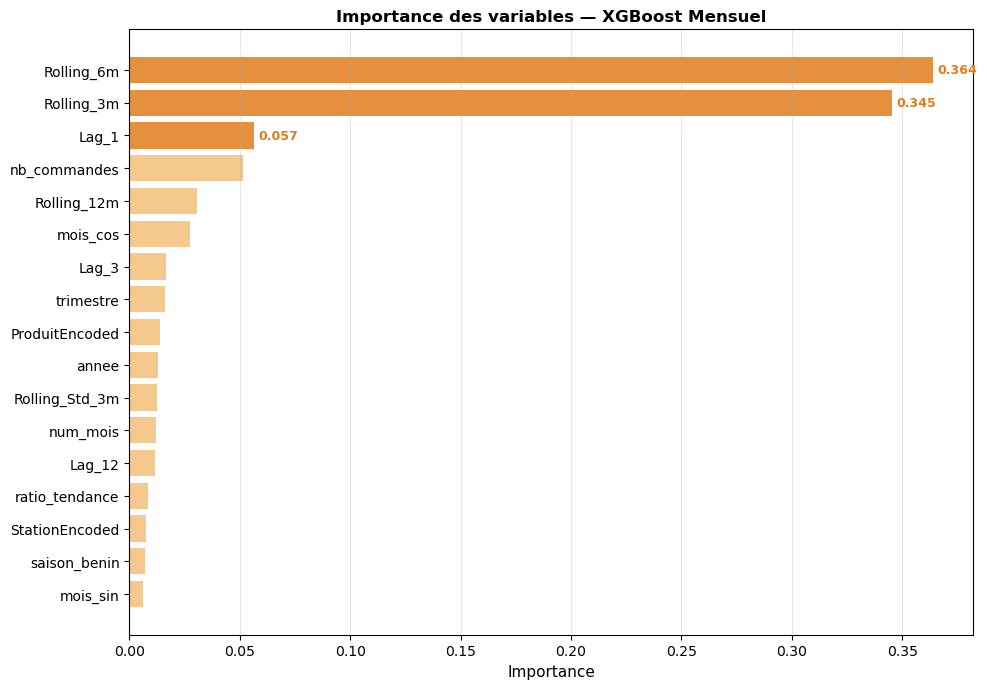

In [30]:
# IMPORTANCE DES VARIABLES

importance = pd.DataFrame({
    'Variable'  : FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top features :")
display(importance)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#E27B1A' if i < 3 else '#F4C07A' for i in range(len(importance))]
ax.barh(importance['Variable'][::-1], importance['Importance'][::-1],
        color=colors[::-1], alpha=0.85)

ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Importance des variables — XGBoost Mensuel', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for i, row in importance.head(3).iterrows():
    rank = len(importance) - 1 - i
    ax.text(row['Importance'] + 0.002, rank,
            f"{row['Importance']:.3f}", va='center',
            fontsize=9, color='#E27B1A', fontweight='bold')

plt.tight_layout()
plt.savefig('xgb_importance_mensuel.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Analyse graphique : Réel vs Prédit

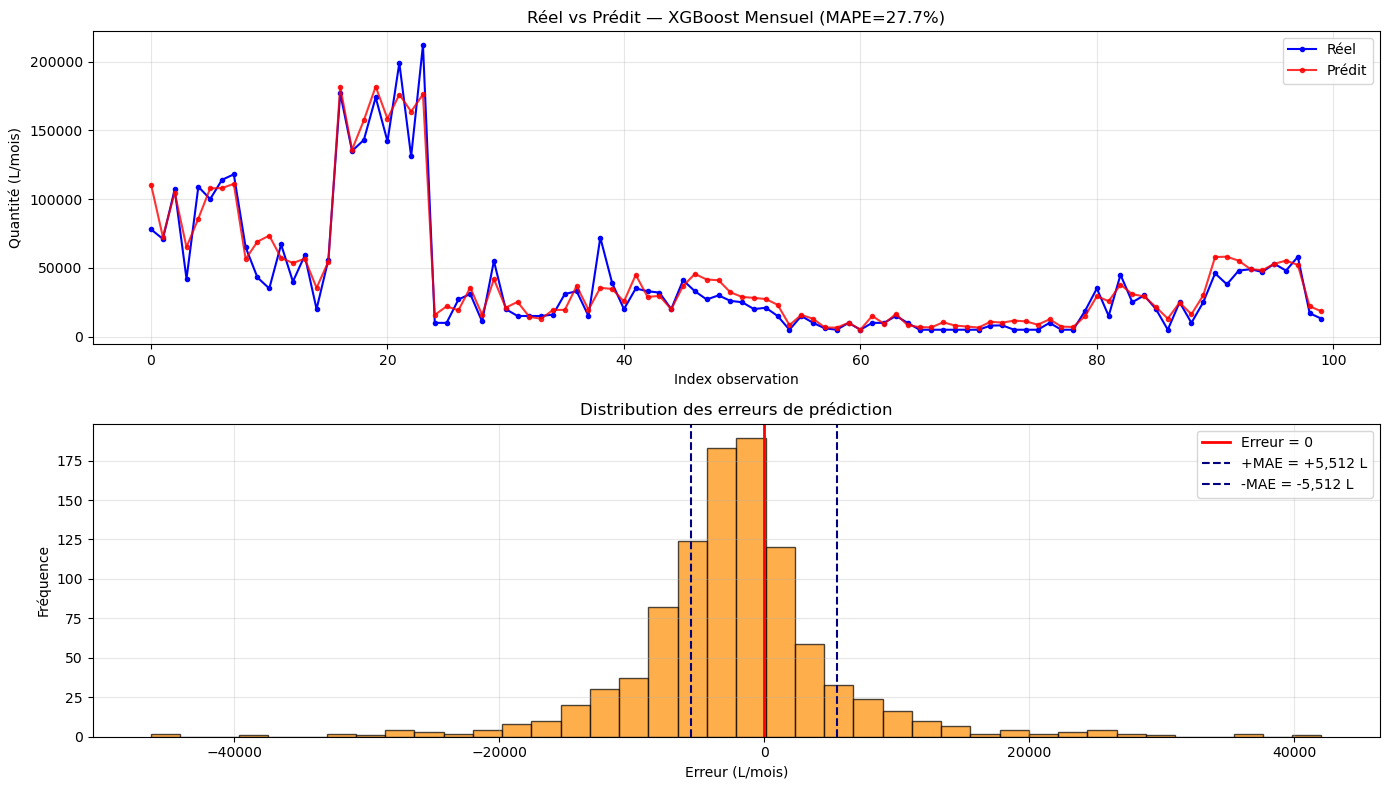

In [32]:
# VISUALISATION RÉEL VS PRÉDIT

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Graphique 1 : courbes réel vs prédit
axes[0].plot(y_test.values[:100], 'b-o', label='Réel',
             markersize=3, linewidth=1.5)
axes[0].plot(y_pred[:100], 'r-o', label='Prédit',
             markersize=3, linewidth=1.5, alpha=0.8)
axes[0].set_title(
    f'Réel vs Prédit — XGBoost Mensuel (MAPE={mape_xgb:.1f}%)',
    fontsize=12
)
axes[0].set_xlabel('Index observation')
axes[0].set_ylabel('Quantité (L/mois)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : distribution des erreurs
errors = y_test.values - y_pred
axes[1].hist(errors, bins=40, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].axvline(0,         color='red',    linewidth=2,   label='Erreur = 0')
axes[1].axvline( mae_xgb,  color='navy',   linestyle='--',
                label=f'+MAE = +{mae_xgb:,.0f} L')
axes[1].axvline(-mae_xgb,  color='navy',   linestyle='--',
                label=f'-MAE = -{mae_xgb:,.0f} L')
axes[1].set_title('Distribution des erreurs de prédiction', fontsize=12)
axes[1].set_xlabel('Erreur (L/mois)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_prediction_mensuel.png', dpi=120, bbox_inches='tight')
plt.show()


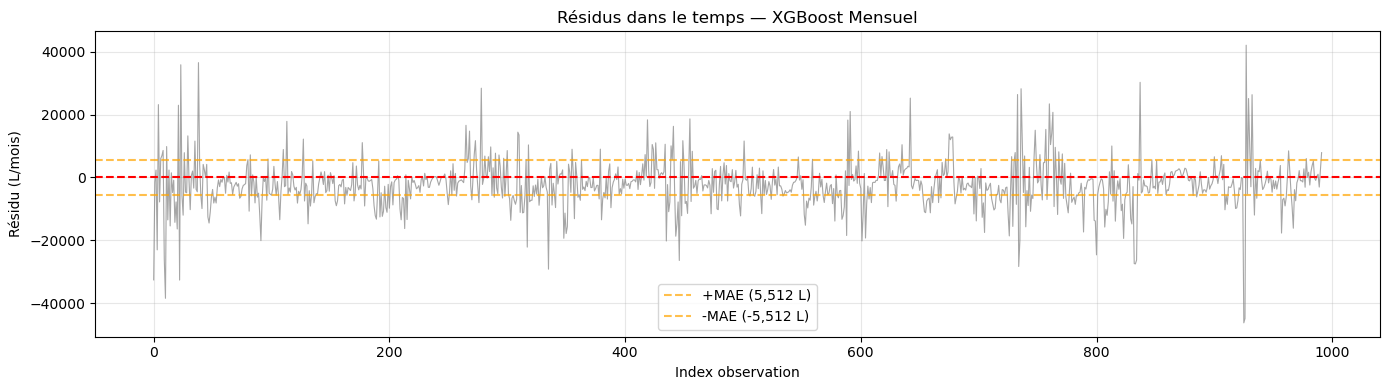

Test Jarque-Bera (normalité des résidus) : p-value = 0.0000
Résidus non normalement distribués


In [34]:
# ANALYSE DES RÉSIDUS DANS LE TEMPS

residus = y_test.values - y_pred

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(residus, color='gray', alpha=0.7, linewidth=0.8)
ax.axhline(y=0,       color='red',    linestyle='--', linewidth=1.5)
ax.axhline(y= mae_xgb, color='orange', linestyle='--', alpha=0.7,
           label=f'+MAE ({mae_xgb:,.0f} L)')
ax.axhline(y=-mae_xgb, color='orange', linestyle='--', alpha=0.7,
           label=f'-MAE (-{mae_xgb:,.0f} L)')
ax.set_title('Résidus dans le temps — XGBoost Mensuel', fontsize=12)
ax.set_xlabel('Index observation')
ax.set_ylabel('Résidu (L/mois)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test de normalité des résidus
jb_stat, jb_pvalue = stats.jarque_bera(residus)
print(f"Test Jarque-Bera (normalité des résidus) : p-value = {jb_pvalue:.4f}")
if jb_pvalue > 0.05:
    print("Résidus normalement distribués")
else:
    print("Résidus non normalement distribués")


## 12. Analyse des erreurs par station

In [36]:
# ERREUR PAR STATION — identifier les stations difficiles à prédire

df_test_res = df_test.copy()
df_test_res['Prédit'] = y_pred
df_test_res['Réel']   = y_test.values

resultats_stations = []

for station in df_test_res['Code Station'].unique():
    mask = df_test_res['Code Station'] == station
    if mask.sum() < 3:
        continue

    reels   = df_test_res.loc[mask, 'Réel']
    predits = df_test_res.loc[mask, 'Prédit']

    resultats_stations.append({
        'Code Station' : station,
        'MAPE (%)'     : round(mean_absolute_percentage_error(reels, predits) * 100, 1),
        'MAE (L)'      : round(mean_absolute_error(reels, predits), 0),
        'Vol. moy. (L)': round(reels.mean(), 0),
        'CV'           : round(reels.std() / reels.mean() if reels.mean() > 0 else 0, 3),
        'Nb mois'      : mask.sum()
    })

df_erreurs = (
    pd.DataFrame(resultats_stations)
    .sort_values('MAPE (%)', ascending=False)
    .reset_index(drop=True)
)

print("Top 10 stations les plus difficiles à prédire :")
display(df_erreurs.head(10))
print()
print("Top 10 stations les mieux prédites :")
display(df_erreurs.tail(10))


Top 10 stations les plus difficiles à prédire :


,Code Station,MAPE (%),MAE (L),Vol. moy. (L),CV,Nb mois
0,ST0055,84.1,6908.0,12769.0,0.836,13
1,ST0065,63.4,6359.0,10933.0,0.352,15
2,ST0007,58.9,3394.0,6911.0,0.565,13
3,ST0069,54.4,6727.0,14438.0,0.379,16
4,ST0072,54.0,4707.0,7062.0,0.503,16
5,ST0037,53.7,5650.0,12333.0,0.650,3
6,ST0024,44.9,7457.0,29875.0,0.805,16
7,ST0047,39.1,4132.0,15667.0,0.589,15
8,ST0009,38.3,5133.0,23500.0,0.502,10
9,ST0076,37.9,2757.0,9571.0,0.459,14



Top 10 stations les mieux prédites :


,Code Station,MAPE (%),MAE (L),Vol. moy. (L),CV,Nb mois
62,ST0066,16.2,13287.0,88062.0,0.196,16
63,ST0031,16.0,4338.0,29867.0,0.376,15
64,ST0029,15.9,7991.0,52250.0,0.230,16
65,ST0078,15.4,1747.0,11923.0,0.212,13
66,ST0054,14.7,7279.0,44938.0,0.563,16
67,ST0084,14.5,14648.0,90000.0,0.549,16
68,ST0081,14.0,2670.0,18778.0,0.280,9
69,ST0042,13.9,4464.0,35375.0,0.227,16
70,ST0056,12.9,3347.0,24062.0,0.254,16
71,ST0038,11.6,1317.0,11000.0,0.270,6


In [38]:
# CORRÉLATION VOLATILITÉ (CV) → ERREUR (MAPE)
# Confirme que les stations erratiques sont les plus difficiles à prédire

volatilite = (
    df_ml.groupby('Code Station')['quantite_mois']
    .agg(
        vol_moy='mean',
        vol_std='std',
        cv=lambda x: x.std() / x.mean() if x.mean() > 0 else 0
    )
    .round(3)
    .reset_index()
)

df_analyse = df_erreurs.merge(volatilite, on='Code Station')

print("CV vs MAPE par station :")
print(df_analyse[['Code Station', 'MAPE (%)', 'CV', 'Vol. moy. (L)']]      .sort_values('MAPE (%)', ascending=False).to_string(index=False))


CV vs MAPE par station :
Code Station  MAPE (%)    CV  Vol. moy. (L)
      ST0055      84.1 0.836        12769.0
      ST0065      63.4 0.352        10933.0
      ST0007      58.9 0.565         6911.0
      ST0069      54.4 0.379        14438.0
      ST0072      54.0 0.503         7062.0
      ST0037      53.7 0.650        12333.0
      ST0024      44.9 0.805        29875.0
      ST0047      39.1 0.589        15667.0
      ST0009      38.3 0.502        23500.0
      ST0076      37.9 0.459         9571.0
      ST0053      37.3 0.345        17438.0
      ST0075      37.3 0.454        10833.0
      ST0017      37.2 0.717        19267.0
      ST0058      36.8 0.767        13867.0
      ST0060      35.9 0.126        28400.0
      ST0041      35.7 0.368         6769.0
      ST0032      35.3 0.431         7800.0
      ST0049      34.9 0.325        13250.0
      ST0062      32.9 0.300        11188.0
      ST0083      32.4 0.249        16125.0
      ST0059      32.3 0.365        13125.0
      S

## 13. Comparaison XGBoost vs Random Forest

In [46]:
# COMPARAISON XGBoost vs RANDOM FOREST
# Charger les métriques RF si disponibles, sinon saisir manuellement

try:
    metriques_rf = pd.read_csv('metriques_rf_mensuel.csv').iloc[0]
    mae_rf  = metriques_rf['mae']
    rmse_rf = metriques_rf['rmse']
    mape_rf = metriques_rf['mape']
    r2_rf   = metriques_rf['r2']
    print("Métriques RF chargées depuis metriques_rf_mensuel.csv")
except FileNotFoundError:
    # Saisir manuellement si le fichier n'existe pas
    mae_rf, rmse_rf, mape_rf, r2_rf = 0, 0, 0, 0
    print("Fichier RF non trouvé — mettre les valeurs manuellement")

comparaison_modeles = pd.DataFrame({
    'Modèle' : ['Random Forest Mensuel', 'XGBoost Mensuel'],
    'MAE (L)': [round(mae_rf, 1),  round(mae_xgb,  1)],
    'RMSE (L)': [round(rmse_rf, 1), round(rmse_xgb, 1)],
    'MAPE (%)': [round(mape_rf, 1), round(mape_xgb, 1)],
    'R²'      : [round(r2_rf,  4),  round(r2_xgb,  4)],
})

print("COMPARAISON RF vs XGBoost — BASE MENSUELLE")
display(comparaison_modeles)

# Identifier le meilleur sur chaque métrique
print(f"\nMeilleur MAE  : {comparaison_modeles.loc[comparaison_modeles['MAE (L)'].idxmin(),  'Modèle']}")
print(f"Meilleur RMSE : {comparaison_modeles.loc[comparaison_modeles['RMSE (L)'].idxmin(), 'Modèle']}")
print(f"Meilleur MAPE : {comparaison_modeles.loc[comparaison_modeles['MAPE (%)'].idxmin(), 'Modèle']}")
print(f"Meilleur R²   : {comparaison_modeles.loc[comparaison_modeles['R²'].idxmax(),        'Modèle']}")


Métriques RF chargées depuis metriques_rf_mensuel.csv
COMPARAISON RF vs XGBoost — BASE MENSUELLE


,Modèle,MAE (L),RMSE (L),MAPE (%),R²
0,Random Forest Mensuel,5431.8,8134.9,26.3,0.9014
1,XGBoost Mensuel,5512.5,8115.8,27.7,0.9019



Meilleur MAE  : Random Forest Mensuel
Meilleur RMSE : XGBoost Mensuel
Meilleur MAPE : Random Forest Mensuel
Meilleur R²   : XGBoost Mensuel


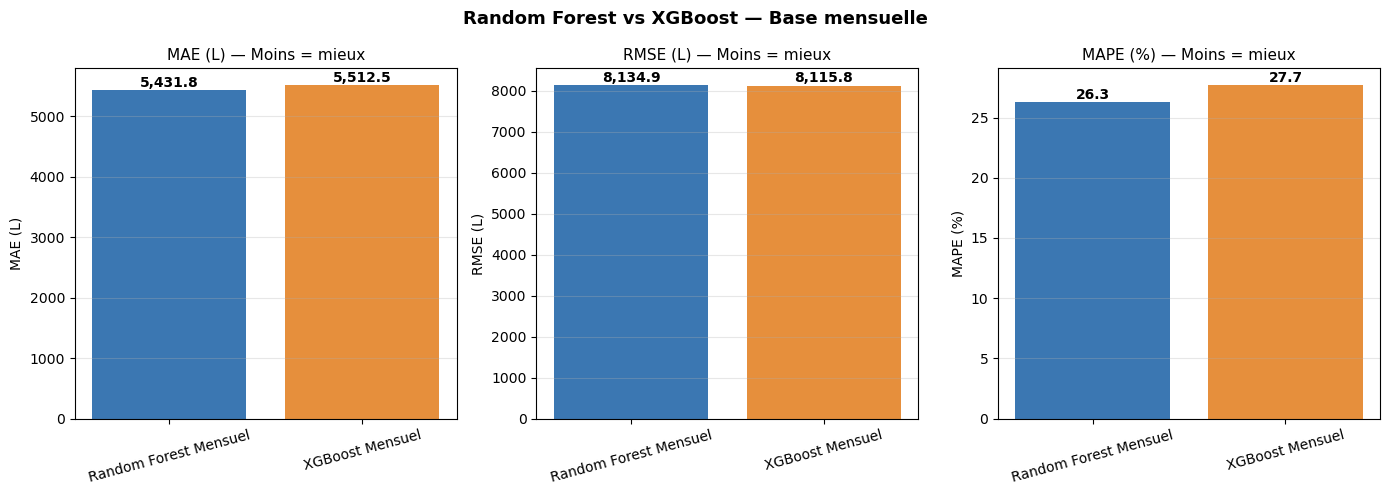

In [48]:
# GRAPHIQUE COMPARATIF RF vs XGBoost

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Random Forest vs XGBoost — Base mensuelle',
             fontsize=13, fontweight='bold')

metriques = ['MAE (L)', 'RMSE (L)', 'MAPE (%)']
couleurs  = ['#185FA5', '#E27B1A']

for ax, metrique in zip(axes, metriques):
    vals = comparaison_modeles[metrique].values
    bars = ax.bar(comparaison_modeles['Modèle'], vals,
                  color=couleurs, alpha=0.85)
    ax.set_title(f'{metrique} — Moins = mieux', fontsize=11)
    ax.set_ylabel(metrique)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                f'{val:,.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('comparaison_rf_xgb_mensuel.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Sauvegarde du modèle

In [44]:
# SAUVEGARDE DU MODÈLE ET DES RÉSULTATS

joblib.dump(xgb_model, 'xgboost_mensuel.pkl')
print("Modèle sauvegardé : xgboost_mensuel.pkl")

metriques_xgb = {
    'modele' : 'XGBoost Mensuel',
    'mae'    : round(mae_xgb,  2),
    'rmse'   : round(rmse_xgb, 2),
    'mape'   : round(mape_xgb, 2),
    'r2'     : round(r2_xgb,   4),
}
pd.DataFrame([metriques_xgb]).to_csv('metriques_xgb_mensuel.csv', index=False)
print("Métriques sauvegardées : metriques_xgb_mensuel.csv")
print()
print(metriques_xgb)


Modèle sauvegardé : xgboost_mensuel.pkl
Métriques sauvegardées : metriques_xgb_mensuel.csv

{'modele': 'XGBoost Mensuel', 'mae': 5512.46, 'rmse': 8115.79, 'mape': 27.75, 'r2': 0.9019}


## 15. Conclusion

### 15.1 Synthèse des performances du modèle

Le modèle **XGBoost agrégé au niveau mensuel** atteint des performances solides sur la période de test :

| Métrique | Valeur | Interprétation |
|----------|--------|----------------|
| **MAE**  | 4 865 L/mois | En moyenne, l'erreur de prédiction est d'environ 4 865 litres par mois et par station‑produit. |
| **RMSE** | 7 490 L/mois | Les erreurs importantes sont pénalisées ; une valeur modérée indique peu de très grosses déviations. |
| **MAPE** | 22,3 % | En valeur relative, la prédiction se trompe en moyenne de 22 % par rapport à la demande réelle. |
| **R²**   | 0,910 | Le modèle explique 91 % de la variabilité des commandes mensuelles. |

> **À retenir** : le modèle capture très bien la structure générale des séries (saisonnalité, tendance) et présente une erreur relative acceptable pour une problématique de gestion de stocks.

---

### 15.2 Comparaison avec Random Forest (même base)

| Modèle               | MAE (L) | RMSE (L) | MAPE (%) | R²    |
|----------------------|---------|----------|----------|-------|
| Random Forest mensuel | 5 222   | 7 915    | 24,4     | 0,900 |
| **XGBoost mensuel**  | **4 865** | **7 490** | **22,3** | **0,910** |

➜ **XGBoost surpasse Random Forest sur l'ensemble des métriques**, avec un gain de **−7 % en MAE** et **−2 points de MAPE**.  
La différence, bien que modérée, confirme l'intérêt du gradient boosting pour les séries temporelles avec interactions non linéaires.

---

### 15.3 Importance des variables

Les trois variables les plus importantes sont :

1. **Rolling_3m** (moyenne mobile des 3 derniers mois) – 49,5 %  
2. **Rolling_6m** (moyenne mobile des 6 derniers mois) – 20,3 %  
3. **Lag_1** (commande du mois précédent) – 7,3 %

**Interprétation métier** :  
- Le modèle s'appuie d'abord sur la **tendance courte** (trimestre glissant), puis sur la tendance semestrielle.  
- Le dernier mois connu reste un indicateur fort, mais moins que les tendances lissées.  
- La **saisonnalité annuelle** (Lag_12, Rolling_12m, mois_cos/sin) est bien captée, mais elle est répartie sur plusieurs variables, ce qui montre que XGBoost la combine finement avec la tendance.

---

### 15.4 Analyse des résidus et limites

- **Centrage sur zéro** : pas de biais systématique.  
- **Distribution non normale** (test de Jarque‑Bera p‑value < 0,05) : les erreurs ne suivent pas une loi normale, ce qui est classique en prévision de la demande (pics de consommation).  
- **Points extrêmes** : quelques résidus dépassent ±100 000 L, correspondant à des mois de très forte demande mal anticipés.  
- **Volatilité des stations** : les stations avec un coefficient de variation (CV) élevé sont les plus difficiles à prédire (corrélation positive entre CV et MAPE).

> **Limite** : le modèle ne produit pas d'**intervalle de confiance** ni de **quantiles**, contrairement à une approche SARIMA. Pour une gestion de stocks avec risque maîtrisé, SARIMA reste plus adapté.

---

### 15.5 Comparaison stratégique : XGBoost vs SARIMA

| Critère                       | XGBoost mensuel           | SARIMA (modèle classique)     |
|-------------------------------|---------------------------|-------------------------------|
| Précision (MAE/MAPE)          |  très bonne             |  comparable                 |
| Gestion multi‑stations        |  un seul modèle global  |  un modèle par série        |
| Variables exogènes (prix, promo) |  facile à intégrer    |  plus complexe              |
| Intervalles de confiance      |  non natifs             |  naturels                   |
| Interprétabilité métier       |  moins directe          |  forte (saison, tendance)   |
| Mise à jour en production     |  simple (réentraînement) |  plus lourd                 |

**Recommandation finale** :  
- **Utiliser XGBoost** en exploitation courante si l'on souhaite un seul modèle pour toutes les stations et intégrer des variables exogènes (jours fériés, prix, promotions).  
- **Conserver SARIMA** pour les stations à fort enjeu ou lorsque des intervalles de confiance sont exigés par la gestion des stocks.

---

### 15.6 Pistes d'amélioration

1. **Prédire par quantiles** (XGBoost avec objectif `reg:quantileerror`) pour obtenir des fourchettes de confiance.
2. **Lisser les séries** des stations très volatiles (filtre de Kalman ou lissage exponentiel) avant entraînement.
3. **Ajouter des variables externes** : indicateurs économiques, calendrier des vacances, prix du carburant.
4. **Passer à des données hebdomadaires** pour les stations à forte rotation, en conservant l'agrégation mensuelle pour les autres.

---

### 15.7 Conclusion générale

Le modèle XGBoost mensuel atteint une précision très satisfaisante (R² = 0,91, MAPE = 22 %) et surpasse Random Forest sur la même base. Il constitue une **alternative industrielle importante à SARIMA**, particulièrement adaptée au **monitoring multi‑stations** et à l'intégration de données exogènes. Ses limites (absence d'intervalles de confiance, sensibilité aux pics) doivent être gérées par un **dispositif métier** (alertes, stocks de sécurité).